# FERM Experiments

Clean workflow for testing GDP-FERM, relational-FERM, and Abel-FERM.

**Fast path:** run sections 1, 2, 3, then either 4A for a quick current-run scatter or 4B for validation tuning. Keep `FAST_TEST=True` while iterating; switch it off only for final runs.

## 1. Setup

Imports and helper functions. This is the only cell that defines `build_abel_sigma`; rerun it after changing Abel normalization.

In [122]:
# Setup: imports and helper functions

from pathlib import Path

import numpy as np
import pandas as pd

from src.ferm.config import Config
import importlib
import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM, RM
from src.ferm.plotting import plot_rm_vs_ferm_error_scatter, plot_timeseries_migrants
from src.ferm.preprocessing import filter_flows_by_continent, split_flows_by_period
from src.ferm.utils import (
    add_niche,
    build_master_country_table,
    load_country_geometries_global,
    load_migration_data,
    load_niche_data,
    load_population_data,
    prepare_nodes,
)


RELATIONAL_FEATURES = {
    "scaled_sci_2021": "positive",
    "comrelig": "positive",
    "tradeflow_baci": "positive",
    "manuf_tradeflow_baci": "positive",
    "dist": "negative",
    "distcap": "negative",
    "distw_harmonic": "negative",
    "distw_arithmetic": "negative",
    "diplo_disagreement": "negative",
}


def rescale_relational_feature(
    values: pd.Series,
    direction: str = "positive",
) -> pd.Series:
    """
    Rescale one bilateral feature to [-1, 1] so different Sigma candidates
    are numerically comparable across runs and 0 keeps a neutral meaning.
    """
    x = pd.to_numeric(values, errors="coerce")
    out = pd.Series(np.nan, index=x.index, dtype=float)

    valid = x.notna()
    if valid.sum() == 0:
        return out

    x_valid = x[valid]
    x_min = x_valid.min()
    x_max = x_valid.max()

    if pd.isna(x_min) or pd.isna(x_max) or x_min == x_max:
        out.loc[valid] = 0.0
        return out

    scaled = 2.0 * (x - x_min) / (x_max - x_min) - 1.0

    if direction == "positive":
        out.loc[valid] = scaled.loc[valid]
    elif direction == "negative":
        out.loc[valid] = -scaled.loc[valid]
    else:
        raise ValueError("`direction` must be 'positive' or 'negative'.")

    return out


def build_relational_feature_table(
    nodes: pd.DataFrame,
    gravity_pairs: pd.DataFrame,
    feature_col: str,
    direction: str,
) -> pd.DataFrame:
    """
    Map CEPII iso3 corridors onto model node codes and create Sigma_ij.
    """
    if "iso3" not in nodes.columns:
        raise ValueError("`nodes` must contain an `iso3` column.")

    code_lookup = nodes[["code", "iso3"]].dropna().drop_duplicates().copy()
    code_lookup["iso3"] = code_lookup["iso3"].astype(str).str.strip().str.upper()

    scoped = gravity_pairs[["iso3_o", "iso3_d", feature_col]].copy()
    scoped["iso3_o"] = scoped["iso3_o"].astype(str).str.strip().str.upper()
    scoped["iso3_d"] = scoped["iso3_d"].astype(str).str.strip().str.upper()

    mapped = scoped.merge(
        code_lookup.rename(columns={"code": "country_from", "iso3": "origin_iso3"}),
        left_on="iso3_o",
        right_on="origin_iso3",
        how="inner",
    )
    mapped = mapped.merge(
        code_lookup.rename(columns={"code": "country_to", "iso3": "destination_iso3"}),
        left_on="iso3_d",
        right_on="destination_iso3",
        how="inner",
    )

    mapped = mapped[mapped["origin_iso3"] != mapped["destination_iso3"]].copy()
    mapped["Sigma_ij"] = rescale_relational_feature(mapped[feature_col], direction)
    mapped = mapped.dropna(subset=["Sigma_ij"]).copy()

    return mapped[
        ["country_from", "country_to", "origin_iso3", "destination_iso3", feature_col, "Sigma_ij"]
    ].drop_duplicates(["origin_iso3", "destination_iso3"])


def build_destination_sigma(nodes: pd.DataFrame, niche_col: str = "niche") -> pd.DataFrame:
    """
    Traditional FERM Sigma: Sigma[i, i] = mu_i and Sigma[i, j] = mu_j.
    """
    node_values = nodes.set_index("iso3")[niche_col].astype(float).fillna(0.0)
    codes = node_values.index.astype(str).str.strip().str.upper().tolist()
    values = node_values.to_numpy()
    return pd.DataFrame(
        np.tile(values, (len(values), 1)),
        index=codes,
        columns=codes,
    )


def build_relational_sigma(
    nodes: pd.DataFrame,
    corridor_features: pd.DataFrame,
    value_col: str = "Sigma_ij",
    fill_value: float = 0.0,
) -> pd.DataFrame:
    """
    Relational FERM Sigma: neutral diagonal and corridor-specific off-diagonal entries.
    """
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    values = np.full((len(codes), len(codes)), float(fill_value), dtype=float)
    np.fill_diagonal(values, 0.0)
    Sigma = pd.DataFrame(values, index=codes, columns=codes)

    for row in corridor_features.itertuples(index=False):
        origin = getattr(row, "origin_iso3")
        destination = getattr(row, "destination_iso3")
        if origin in Sigma.index and destination in Sigma.columns and origin != destination:
            Sigma.loc[origin, destination] = float(getattr(row, value_col))

    return Sigma


def build_abel_sigma(
    nodes: pd.DataFrame,
    abel_path: str | Path = "abel-database-s2.xlsx",
    sheet_name: str = "2005-10",
    normalize_by: str = "row_share",
    transform: str = "row_share_log_centered_clipped",
    fill_value: float = 0.0,
    epsilon: float = 1e-6,
    smooth_alpha: float = 0.05,
    clip_value: float = 1.0,
) -> pd.DataFrame:
    """
    Build a relational-FERM Sigma matrix from Abel bilateral migration stocks.

    Pure relational FERM keeps Sigma[i, i] = 0 and uses off-diagonal
    Sigma[i, j] = delta_ij as a signed corridor-specific offer shift.

    Supported main specifications:
    - Option A: normalize_by='row_share', transform='row_share_log_centered_clipped'.
      This is origin-conditioned historical destination preference.
    - Option B: normalize_by='expected_stock', transform='expected_log_ratio_tanh'.
      This is a fixed, softly bounded observed-vs-expected dyadic affinity.
    """
    raw = pd.read_excel(abel_path, sheet_name=sheet_name, header=None)

    destination_codes = raw.iloc[2, 3:-1].astype(str).str.strip().str.upper().tolist()
    matrix = raw.iloc[3:, 3:-1].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    origin_codes = raw.iloc[3:, 2].astype(str).str.strip().str.upper().tolist()
    abel = pd.DataFrame(matrix.to_numpy(dtype=float), index=origin_codes, columns=destination_codes)
    abel = abel.groupby(level=0).sum()
    abel = abel.T.groupby(level=0).sum().T

    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    stocks = abel.reindex(index=codes, columns=codes).fillna(float(fill_value)).astype(float)
    stock_values = stocks.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(stock_values, 0.0)
    stocks = pd.DataFrame(stock_values, index=codes, columns=codes)

    populations = nodes.set_index("iso3")["population"].astype(float)
    populations.index = populations.index.astype(str).str.strip().str.upper()
    populations = populations.reindex(codes).replace(0.0, np.nan)

    expected = None
    if normalize_by == "row_share":
        row_totals = stocks.sum(axis=1).replace(0.0, np.nan)
        normalized = stocks.div(row_totals, axis="index")
    elif normalize_by == "column_share":
        column_totals = stocks.sum(axis=0).replace(0.0, np.nan)
        normalized = stocks.div(column_totals, axis="columns")
    elif normalize_by == "expected_stock":
        row_totals = stocks.sum(axis=1).to_numpy(dtype=float)
        column_totals = stocks.sum(axis=0).to_numpy(dtype=float)
        total_stock = float(stocks.to_numpy(dtype=float).sum())
        expected_values = np.outer(row_totals, column_totals)
        if total_stock > 0:
            expected_values = expected_values / total_stock
        else:
            expected_values = np.full_like(expected_values, np.nan, dtype=float)
        np.fill_diagonal(expected_values, 0.0)
        expected = pd.DataFrame(expected_values, index=codes, columns=codes)
        normalized = stocks.copy()
    elif normalize_by == "destination":
        normalized = stocks.div(populations, axis="columns")
    elif normalize_by == "origin":
        normalized = stocks.div(populations, axis="index")
    else:
        raise ValueError(
            "normalize_by must be 'row_share', 'column_share', 'expected_stock', "
            "'destination', or 'origin'."
        )

    normalized = normalized.replace([np.inf, -np.inf], np.nan).fillna(float(fill_value))
    values = normalized.to_numpy(dtype=float, copy=True)
    off_diag = ~np.eye(len(codes), dtype=bool)

    if transform == "row_share_log_centered_clipped":
        for row_idx in range(len(codes)):
            row_mask = np.ones(len(codes), dtype=bool)
            row_mask[row_idx] = False
            n_destinations = max(int(row_mask.sum()), 1)
            row_values = values[row_idx, row_mask]
            row_values = (row_values + float(smooth_alpha) / n_destinations) / (1.0 + float(smooth_alpha))
            row_values = np.log(row_values + float(epsilon))
            center = np.nanmean(row_values)
            row_values = row_values - center
            values[row_idx, row_mask] = np.clip(row_values, -float(clip_value), float(clip_value))
    elif transform == "expected_log_ratio_tanh":
        if expected is None:
            raise ValueError("expected_log_ratio_tanh requires normalize_by='expected_stock'.")
        observed_values = stocks.to_numpy(dtype=float, copy=True)
        expected_values = expected.to_numpy(dtype=float, copy=True)
        # Fixed soft residual: A = E maps to 0, A = 0 maps to tanh(-log 2),
        # and very over-represented corridors approach +1 smoothly.
        safe_expected = np.maximum(expected_values, float(epsilon))
        ratio = (observed_values + safe_expected) / (2.0 * safe_expected)
        values = np.tanh(np.log(ratio))
        values[~off_diag] = 0.0
    elif transform == "expected_log_ratio_clipped":
        if expected is None:
            raise ValueError("expected_log_ratio_clipped requires normalize_by='expected_stock'.")
        observed_values = stocks.to_numpy(dtype=float, copy=True)
        expected_values = expected.to_numpy(dtype=float, copy=True)
        values = np.log((observed_values + float(epsilon)) / (expected_values + float(epsilon)))
        values[~off_diag] = 0.0
        values[off_diag] = np.clip(values[off_diag], -float(clip_value), float(clip_value))
    elif transform == "row_log_centered":
        values = np.log(values + float(epsilon))
        for row_idx in range(len(codes)):
            row_mask = np.ones(len(codes), dtype=bool)
            row_mask[row_idx] = False
            center = np.nanmean(values[row_idx, row_mask])
            values[row_idx, :] = values[row_idx, :] - center
    elif transform == "log_zscore":
        values = np.log1p(values)
        reference = values[off_diag]
        center = np.nanmean(reference)
        scale = np.nanstd(reference)
        values = (values - center) / scale if scale > 0 else values - center
    elif transform == "row_log_zscore":
        values = np.log1p(values)
        for row_idx in range(len(codes)):
            row_mask = np.ones(len(codes), dtype=bool)
            row_mask[row_idx] = False
            reference = values[row_idx, row_mask]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[row_idx, :] = (values[row_idx, :] - center) / scale
            else:
                values[row_idx, :] = values[row_idx, :] - center
    elif transform == "column_log_zscore":
        values = np.log1p(values)
        for col_idx in range(len(codes)):
            col_mask = np.ones(len(codes), dtype=bool)
            col_mask[col_idx] = False
            reference = values[col_mask, col_idx]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[:, col_idx] = (values[:, col_idx] - center) / scale
            else:
                values[:, col_idx] = values[:, col_idx] - center
    elif transform == "column_log_zscore_clipped":
        values = np.log1p(values)
        for col_idx in range(len(codes)):
            col_mask = np.ones(len(codes), dtype=bool)
            col_mask[col_idx] = False
            reference = values[col_mask, col_idx]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[:, col_idx] = (values[:, col_idx] - center) / scale
            else:
                values[:, col_idx] = values[:, col_idx] - center
        values = np.clip(values, -1.0, 1.0)
    elif transform == "zscore":
        reference = values[off_diag]
        center = np.nanmean(reference)
        scale = np.nanstd(reference)
        values = (values - center) / scale if scale > 0 else values - center
    elif transform == "minmax_centered":
        reference = values[off_diag]
        min_value = np.nanmin(reference)
        max_value = np.nanmax(reference)
        if max_value > min_value:
            values = 2.0 * (values - min_value) / (max_value - min_value) - 1.0
        else:
            values = np.zeros_like(values)
    else:
        raise ValueError(
            "transform must be 'row_share_log_centered_clipped', "
            "'expected_log_ratio_tanh', 'expected_log_ratio_clipped', 'row_log_centered', 'log_zscore', "
            "'row_log_zscore', 'column_log_zscore', 'column_log_zscore_clipped', "
            "'zscore', or 'minmax_centered'."
        )

    values = np.nan_to_num(values, nan=float(fill_value), posinf=float(fill_value), neginf=float(fill_value))
    np.fill_diagonal(values, 0.0)
    return pd.DataFrame(values, index=codes, columns=codes)


ABEL_SIGMA_SPECS = {
    "option_a": {
        "label": "Abel Option A: row-share preference",
        "params": {
            "normalize_by": "row_share",
            "transform": "row_share_log_centered_clipped",
            "epsilon": 1e-6,
            "smooth_alpha": 0.05,
            "clip_value": 1.0,
        },
    },
    "option_b": {
        "label": "Abel Option B: expected-stock residual tanh",
        "params": {
            "normalize_by": "expected_stock",
            "transform": "expected_log_ratio_tanh",
            "epsilon": 1e-12,
        },
    },
}


def build_abel_sigma_from_spec(
    nodes: pd.DataFrame,
    spec_name: str = "option_b",
    **overrides,
) -> pd.DataFrame:
    """Build Abel Sigma using a named normalization specification."""
    if spec_name not in ABEL_SIGMA_SPECS:
        valid = ", ".join(ABEL_SIGMA_SPECS)
        raise ValueError(f"Unknown Abel spec {spec_name!r}. Choose one of: {valid}.")

    params = ABEL_SIGMA_SPECS[spec_name]["params"].copy()
    params.update(overrides)
    return build_abel_sigma(nodes=nodes, **params)

def build_gravity_distance_matrix(
    nodes: pd.DataFrame,
    gravity_pairs: pd.DataFrame,
    distance_col: str = "dist",
) -> pd.DataFrame:
    """
    Build an ISO3-by-ISO3 distance matrix from CEPII Gravity distances.
    Rows are origins and columns are destinations.
    """
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    scoped = gravity_pairs[["iso3_o", "iso3_d", distance_col]].copy()
    scoped["iso3_o"] = scoped["iso3_o"].astype(str).str.strip().str.upper()
    scoped["iso3_d"] = scoped["iso3_d"].astype(str).str.strip().str.upper()
    scoped[distance_col] = pd.to_numeric(scoped[distance_col], errors="coerce")

    pivot = scoped.pivot_table(
        index="iso3_o",
        columns="iso3_d",
        values=distance_col,
        aggfunc="mean",
    )
    distances = pivot.reindex(index=codes, columns=codes)
    distances = distances.combine_first(distances.T)

    values = distances.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(values, 0.0)
    distances = pd.DataFrame(values, index=codes, columns=codes)

    if distances.isna().any().any():
        missing = [
            (origin, destination)
            for origin in distances.index
            for destination in distances.columns
            if pd.isna(distances.loc[origin, destination])
        ]
        raise ValueError(
            f"CEPII `{distance_col}` is missing {len(missing)} node-pair distances; "
            f"first missing pairs: {missing[:10]}"
        )

    return distances


def summarize_comparison(comp: pd.DataFrame, label: str) -> dict[str, float | str]:
    comp = comp.copy()
    observed_col = "total_migrants" if "total_migrants" in comp.columns else "num_migrants"

    return {
        "model": label,
        "pairs": len(comp),
        "observed_total": comp[observed_col].sum(),
        "predicted_total": comp["predicted_migrants"].sum(),
        "MAE": np.mean(np.abs(comp["predicted_migrants"] - comp[observed_col])),
        "RMSE": np.sqrt(np.mean((comp["predicted_migrants"] - comp[observed_col]) ** 2)),
        "Pearson": comp[observed_col].corr(comp["predicted_migrants"], method="pearson"),
        "Spearman": comp[observed_col].corr(comp["predicted_migrants"], method="spearman"),
        "Pearson_log": np.log10(comp[observed_col] + 1).corr(
            np.log10(comp["predicted_migrants"] + 1),
            method="pearson",
        ),
        "Spearman_log": np.log10(comp[observed_col] + 1).corr(
            np.log10(comp["predicted_migrants"] + 1),
            method="spearman",
        ),
        "Median_abs_log_ratio": np.median(
            np.abs(np.log10((comp["predicted_migrants"] + 1) / (comp[observed_col] + 1)))
        ),
    }


## 2. Main Run

Runs RM, GDP-FERM, Abel-FERM, and selected relational features for `only_label`. Use `FAST_TEST=True` for quick tests.

Computing period: test_2019_h2 | particles=100000 | sigma=5.0
                          model  pairs  observed_total  predicted_total         MAE         RMSE  Pearson  Spearman  Pearson_log  Spearman_log  Median_abs_log_ratio
                           FERM   2070       6186048.0        6186048.0 4279.513632 17637.953556 0.247709  0.712133     0.700854      0.712133              0.865964
             FERM_abel_option_b   2070       6186048.0        6186048.0 4438.768764 19617.772736 0.177662  0.640553     0.645791      0.640553              1.041393
       FERM_relational_comrelig   2070       6186048.0        6186048.0 4380.964236 18573.707664 0.174459  0.637761     0.648358      0.637761              0.982124
FERM_relational_scaled_sci_2021   2070       6186048.0        6186048.0 4286.121872 18152.596191 0.198389  0.657167     0.658339      0.657167              0.950400
                             RM   2070       6186048.0        6186048.0 4384.796104 18917.088907 0.182578  0.6556

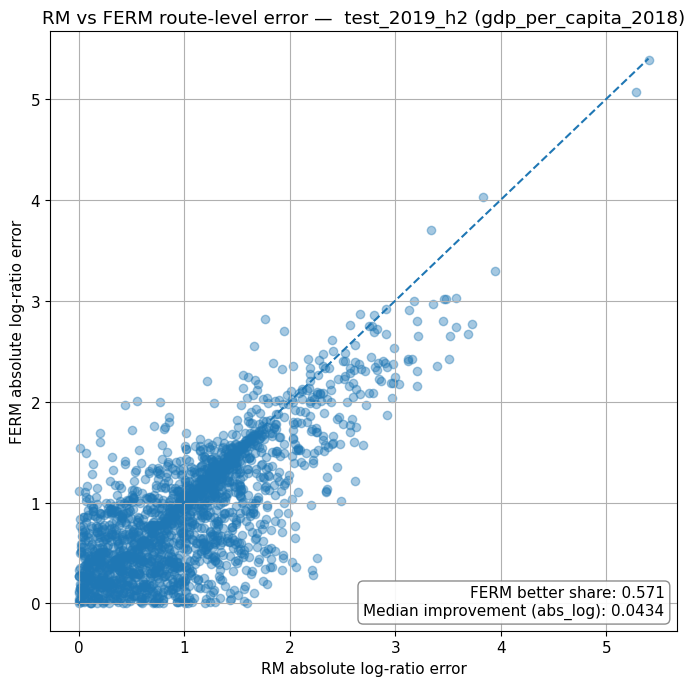

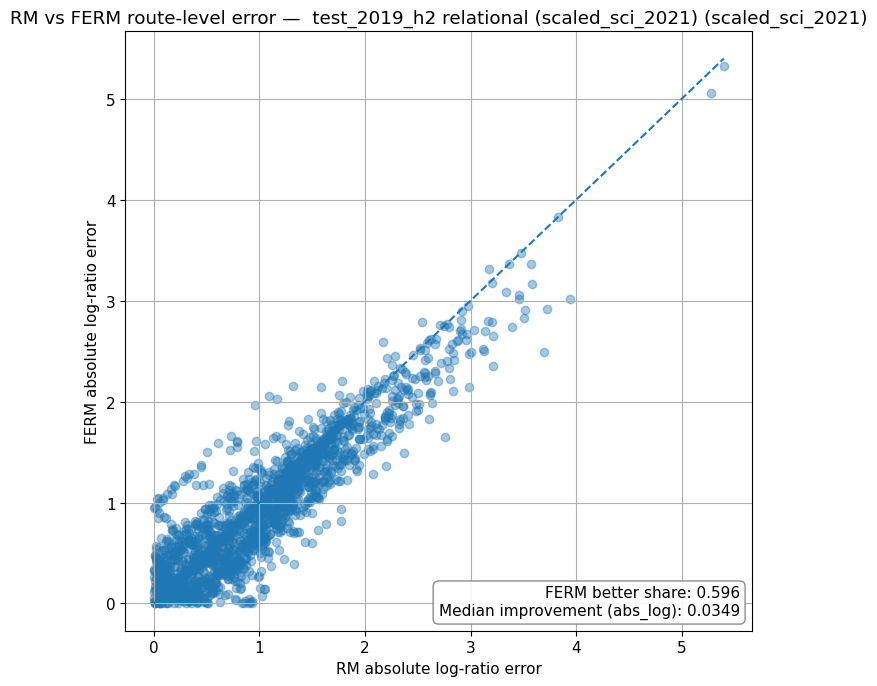

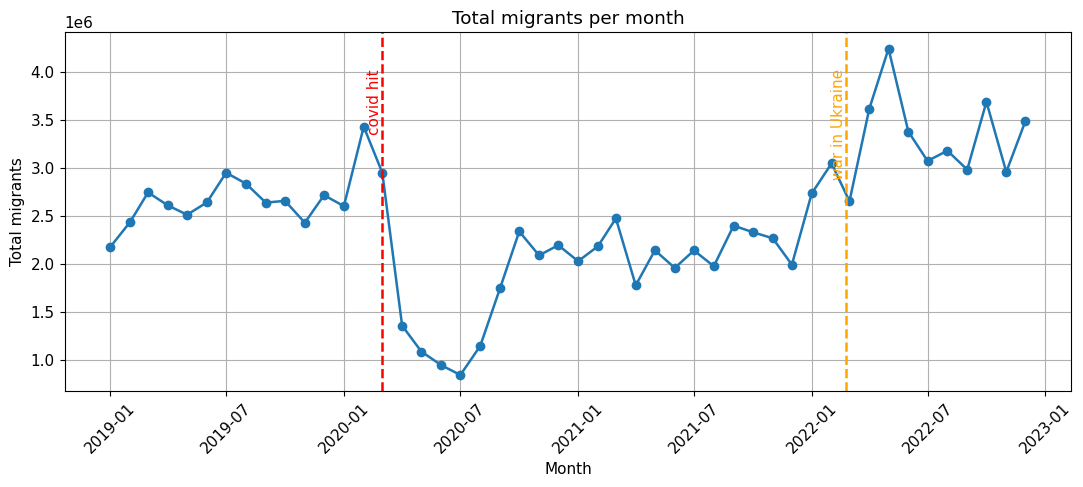

In [123]:
# Main run parameters

FAST_TEST = True  # quick iteration; set False for the final/high-particle run

config = Config(
    niche_method="zscore_log",
    niche_type="gdp_per_capita_2018",
    target_continent="Asia",
    num_particles=100000 if FAST_TEST else 5000000,
    sigma=5.0,
    verbose=True,
)

gravity_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")
relational_feature_year = 2019
distance_col = "dist"
abel_sheet_name = "2005-10"
abel_spec_name = "option_b"  # "option_a" row-share; "option_b" expected-stock residual
abel_spec_overrides = {}  # keep empty for the one-parameter Option B method
relational_features_to_run = [
    "scaled_sci_2021",
    "comrelig",
]
only_label = "test_2019_h2"  # set None to run all periods


# %% Data preparation

migrations = load_migration_data(config.flow_path)
populations = load_population_data(config.pop_path)

gravity_pairs = pd.read_csv(
    gravity_path,
    usecols=["year", "iso3_o", "iso3_d", distance_col] + relational_features_to_run,
)
gravity_pairs = gravity_pairs[gravity_pairs["year"] == relational_feature_year].copy()

world_gdf, country_geo = load_country_geometries_global()

if config.target_continent == "Americas":
    continent_gdf = world_gdf[
        world_gdf["CONTINENT"].isin(["North America", "South America", "Central America"])
    ].copy()
elif config.target_continent is None:
    continent_gdf = world_gdf.copy()
else:
    continent_gdf = world_gdf[world_gdf["CONTINENT"] == config.target_continent].copy()

niche_df = load_niche_data(config.gdp_path, niche_type=config.niche_type)

master_country = build_master_country_table(
    country_geo,
    populations,
    niche_df=niche_df,
    niche_col=config.niche_type,
)

flows, country = filter_flows_by_continent(
    master_country,
    migrations,
    niche_type=config.niche_type,
    continent=config.target_continent,
)

pair_lookup = split_flows_by_period(flows, master_country)

country = add_niche(
    country,
    niche_col=config.niche_type,
    method=config.niche_method,
)


# %% Main comparison loop

comparisons_rm: dict[str, dict[str, object]] = {}
comparisons_ferm: dict[str, dict[str, object]] = {}
comparisons_relational: dict[str, dict[str, dict[str, object]]] = {}
comparisons_abel: dict[str, dict[str, object]] = {}
summary_rows: list[dict[str, float | str]] = []

for label, flows_partial in pair_lookup.items():
    flows_partial = flows_partial.rename({"total_migrants": "num_migrants"}, axis=1)

    if only_label is not None and label != only_label:
        continue
    if len(flows_partial) == 0:
        continue

    print(f"Computing period: {label} | particles={config.num_particles} | sigma={config.sigma}")

    nodes_period = prepare_nodes(country, flows_partial)
    distance_matrix = build_gravity_distance_matrix(
        nodes_period,
        gravity_pairs,
        distance_col=distance_col,
    )

    rm = RM(nodes=nodes_period, flows=flows_partial, distance_matrix=distance_matrix)
    rm_results = rm.run()
    comparisons_rm[label] = {
        "nodes": nodes_period,
        "D": rm_results.distance_matrix,
        "S": rm_results.intervening_population_matrix,
        "P": rm_results.probability_matrix,
        "comparison": rm_results.comparison,
    }
    summary_rows.append(summarize_comparison(rm_results.comparison, label="RM"))

    destination_sigma = build_destination_sigma(nodes_period, niche_col="niche")
    ferm = FERM(
        nodes=nodes_period,
        flows=flows_partial,
        features=destination_sigma,
        distance_matrix=distance_matrix,
    )
    ferm_results = ferm.run(
        num_particles=config.num_particles,
        sigma=config.sigma,
        niche_col="niche",
        verbose=False,
    )
    comparisons_ferm[label] = {
        "nodes": nodes_period,
        "D": ferm_results.distance_matrix,
        "P": ferm_results.probability_matrix,
        "comparison": ferm_results.comparison,
    }
    summary_rows.append(summarize_comparison(ferm_results.comparison, label="FERM"))


    abel_sigma = build_abel_sigma_from_spec(
        nodes=nodes_period,
        spec_name=abel_spec_name,
        abel_path="abel-database-s2.xlsx",
        sheet_name=abel_sheet_name,
        **abel_spec_overrides,
    )
    abel_model = FERM(
        nodes=nodes_period,
        flows=flows_partial,
        features=abel_sigma,
        distance_matrix=distance_matrix,
    )
    abel_results = abel_model.run(
        num_particles=config.num_particles,
        sigma=config.sigma,
        verbose=False,
    )
    comparisons_abel[label] = {
        "nodes": nodes_period,
        "D": abel_results.distance_matrix,
        "Sigma": abel_sigma,
        "P": abel_results.probability_matrix,
        "comparison": abel_results.comparison,
        "spec_name": abel_spec_name,
        "spec_label": ABEL_SIGMA_SPECS[abel_spec_name]["label"],
    }
    summary_rows.append(
        summarize_comparison(
            abel_results.comparison,
            label=f"FERM_abel_{abel_spec_name}",
        )
    )

    comparisons_relational[label] = {}

    for feature_name in relational_features_to_run:
        direction = RELATIONAL_FEATURES[feature_name]
        relational_pairs = build_relational_feature_table(
            nodes=nodes_period,
            gravity_pairs=gravity_pairs,
            feature_col=feature_name,
            direction=direction,
        )

        sigma_matrix = build_relational_sigma(
            nodes=nodes_period,
            corridor_features=relational_pairs,
            value_col="Sigma_ij",
            fill_value=0.0,
        )

        relational_model = FERM(
            nodes=nodes_period,
            flows=flows_partial,
            features=sigma_matrix,
            distance_matrix=distance_matrix,
        )
        relational_results = relational_model.run(
            num_particles=config.num_particles,
            sigma=config.sigma,
            verbose=False,
        )

        comparisons_relational[label][feature_name] = {
            "nodes": nodes_period,
            "D": relational_results.distance_matrix,
            "Sigma": sigma_matrix,
            "corridor_features": relational_pairs,
            "P": relational_results.probability_matrix,
            "comparison": relational_results.comparison,
        }
        summary_rows.append(
            summarize_comparison(
                relational_results.comparison,
                label=f"FERM_relational_{feature_name}",
            )
        )


# %% Summaries

summary_df = pd.DataFrame(summary_rows)
if len(summary_df) > 0:
    print(summary_df.sort_values("model").to_string(index=False))


# %% Plot one baseline comparison plus one relational feature

plot_feature = "scaled_sci_2021"

comp_rm = comparisons_rm[only_label]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)
comp_ferm = comparisons_ferm[only_label]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)
comp_rel = comparisons_relational[only_label][plot_feature]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_ferm,
    label=only_label,
    metric="abs_log",
    niche_type=config.niche_type,
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_rel,
    label=f"{only_label} relational ({plot_feature})",
    metric="abs_log",
    niche_type=plot_feature,
)


# %% Time series

plot_timeseries_migrants(migrations)


## 3. Quick Current-Run Plot

Shows whether the Abel result from the main run improves route-level error relative to RM.

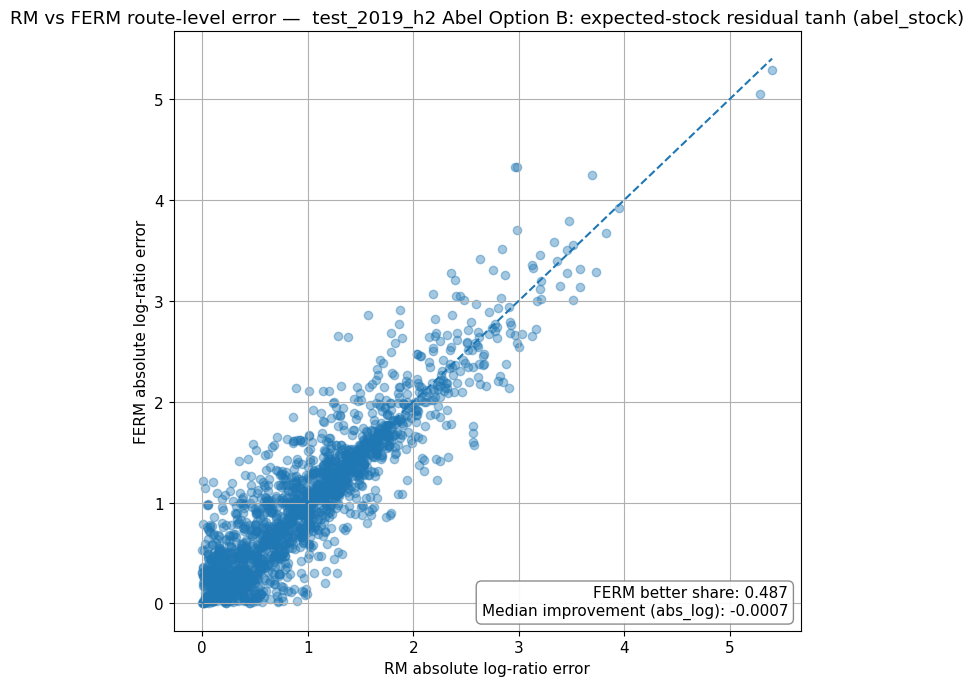

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,residual_rm,abs_error_rm,log_ratio_rm,abs_log_ratio_rm,predicted_ferm,residual_ferm,abs_error_ferm,log_ratio_ferm,abs_log_ratio_ferm,improvement_abs_error,improvement_abs_log
0,AFG,ARE,Afghanistan,United Arab Emirates,5743.0,5.044662,-5737.955338,5737.955338,-2.977842,2.977842,14.250595,-5728.749405,5728.749405,-2.575928,2.575928,9.205932,0.401915
1,AFG,ARM,Afghanistan,Armenia,5.0,1.461523,-3.538477,3.538477,-0.386947,0.386947,2.514811,-2.485189,2.485189,-0.232249,0.232249,1.053288,0.154698
2,AFG,AZE,Afghanistan,Azerbaijan,101.0,5.067951,-95.932049,95.932049,-1.225558,1.225558,12.154919,-88.845081,88.845081,-0.889512,0.889512,7.086968,0.336046
3,AFG,BGD,Afghanistan,Bangladesh,55.0,71.826662,16.826662,16.826662,0.114102,0.114102,78.797406,23.797406,23.797406,0.153801,0.153801,-6.970744,-0.039698
4,AFG,BHR,Afghanistan,Bahrain,22.0,0.743880,-21.256120,21.256120,-1.120211,1.120211,0.838270,-21.161730,21.161730,-1.097318,1.097318,0.094391,0.022893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,YEM,TLS,Yemen,East Timor,2.0,0.208860,-1.791140,1.791140,-0.394745,0.394745,0.394531,-1.605469,1.605469,-0.332693,0.332693,0.185671,0.062052
2066,YEM,TUR,Yemen,Turkey,693.0,513.912842,-179.087158,179.087158,-0.129626,0.129626,407.945106,-285.054894,285.054894,-0.229694,0.229694,-105.967736,-0.100069
2067,YEM,TWN,Yemen,Taiwan,13.0,4.141623,-8.858377,8.858377,-0.435028,0.435028,6.707028,-6.292972,6.292972,-0.259241,0.259241,2.565405,0.175787
2068,YEM,UZB,Yemen,Uzbekistan,34.0,12.133632,-21.866368,21.866368,-0.425683,0.425683,18.937490,-15.062510,15.062510,-0.244398,0.244398,6.803858,0.181286


In [124]:
# Quick Abel scatter for the current main run

comp_abel = comparisons_abel[only_label]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_abel,
    label=f"{only_label} {ABEL_SIGMA_SPECS[abel_spec_name]['label']}",
    metric="abs_log",
    niche_type="abel_stock",
)


## 4A. Optional Sigma-Only Sweep

Quickly checks model `sigma` for the current Abel transform. By default this displays only a summary table, not one plot per sigma.

Running Abel FERM with sigma=0.25


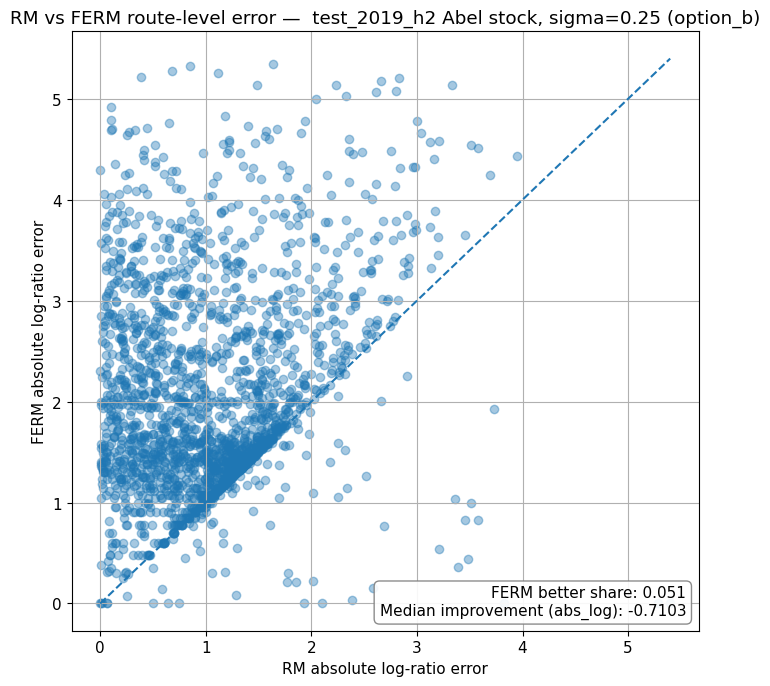

Running Abel FERM with sigma=0.5


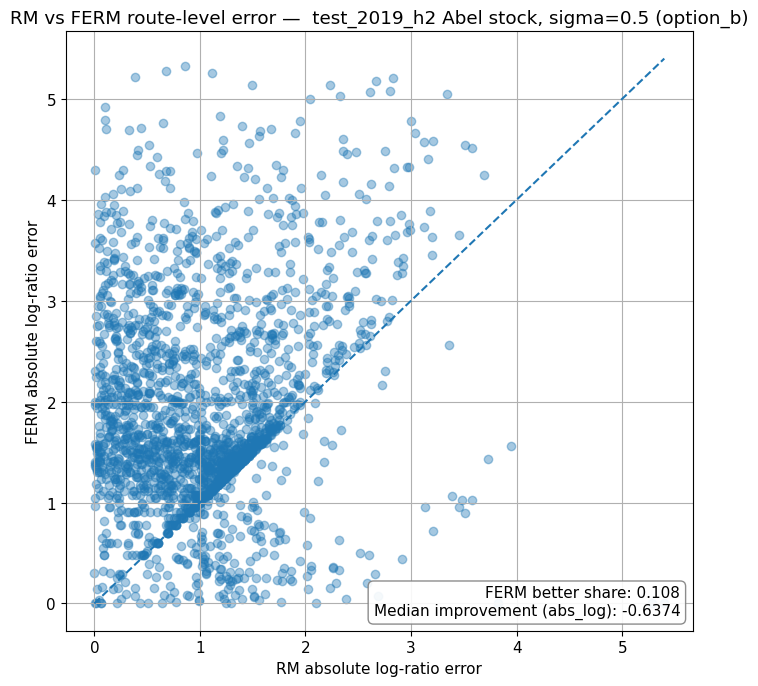

Running Abel FERM with sigma=1.0


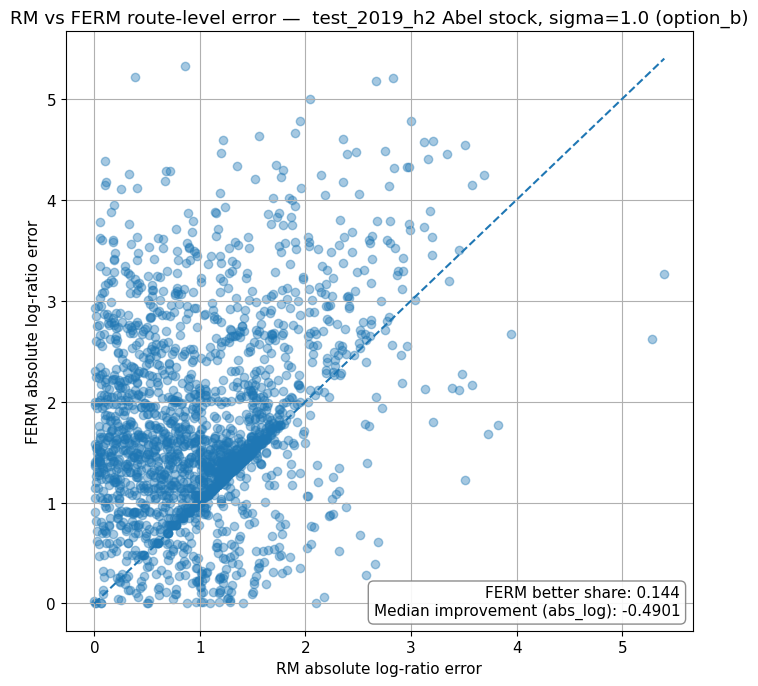

Running Abel FERM with sigma=2.0


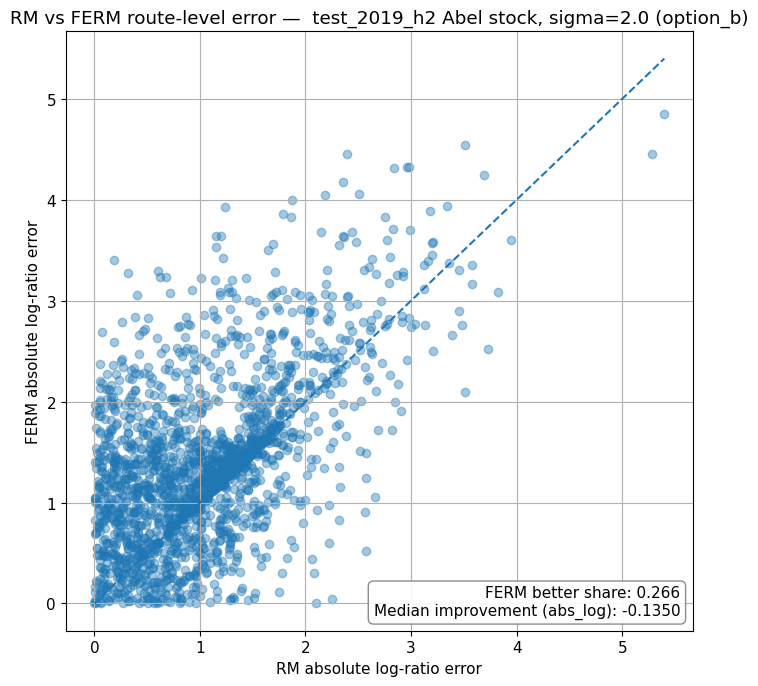

Running Abel FERM with sigma=5.0


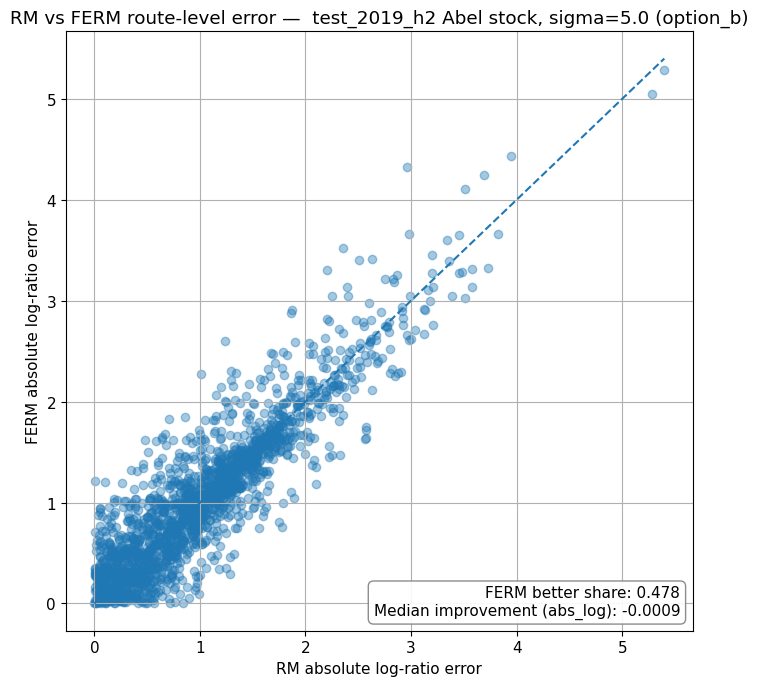

Running Abel FERM with sigma=10.0


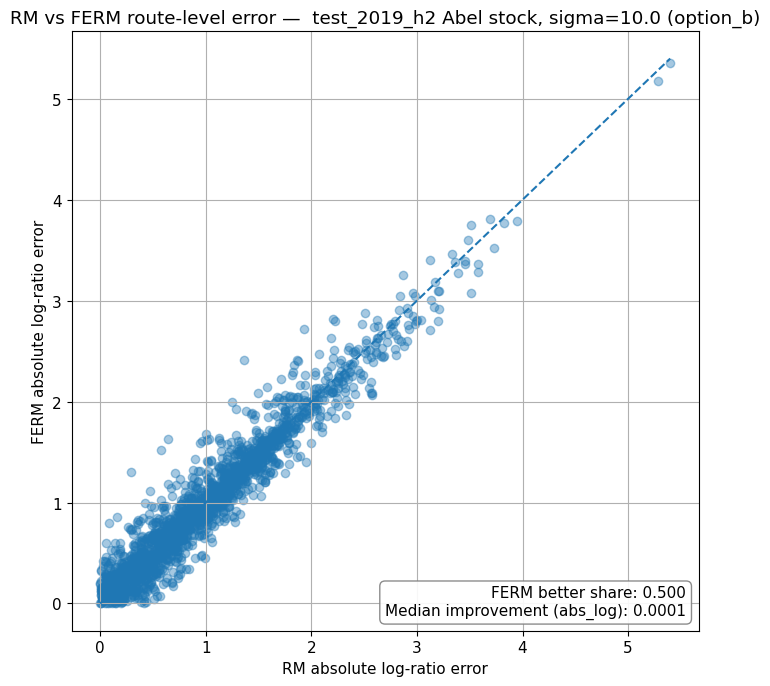

Running Abel FERM with sigma=15.0


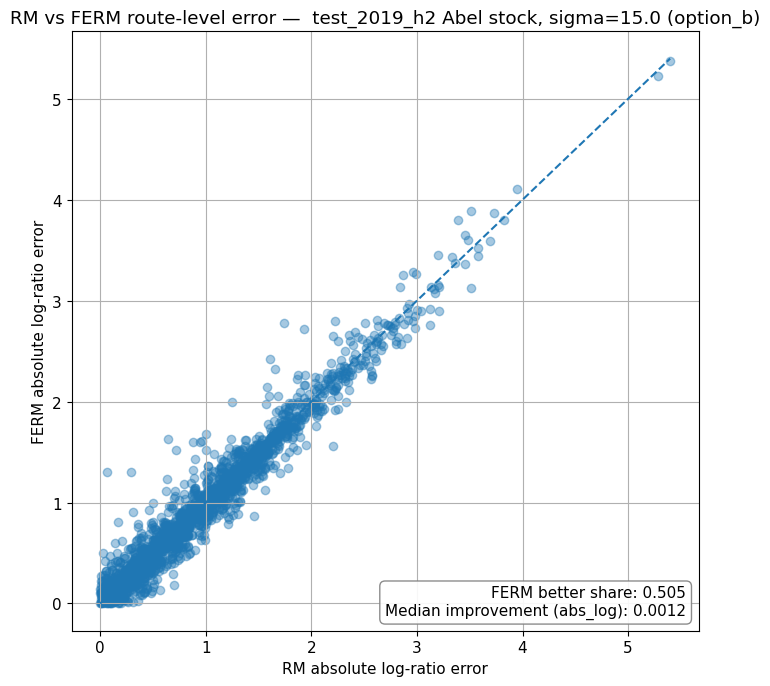

Running Abel FERM with sigma=20.0


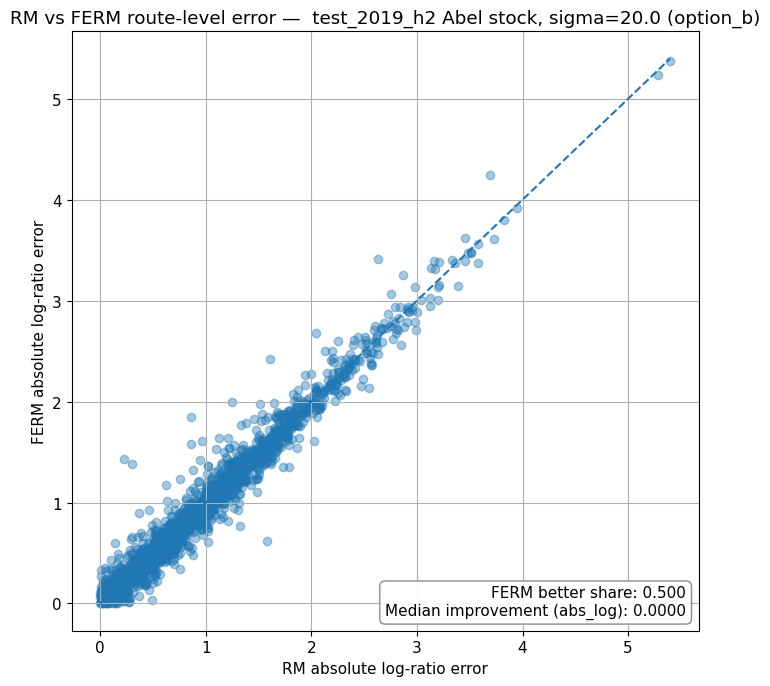

,sigma,num_particles,median_improvement_abs_log,share_better_abs_log,mean_improvement_abs_log
6,15.00,100000,0.001196,0.505314,0.000753
5,10.00,100000,0.000085,0.500000,0.000195
7,20.00,100000,0.000047,0.500483,0.002829
4,5.00,100000,-0.000926,0.478261,-0.022860
3,2.00,100000,-0.135044,0.266184,-0.310372
2,1.00,100000,-0.490114,0.143961,-0.688221
1,0.50,100000,-0.637393,0.107729,-0.838526
0,0.25,100000,-0.710335,0.050725,-0.971326


In [125]:
# Optional quick sigma-only sweep for Abel

import importlib
import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM, RM
from src.ferm.plotting import plot_rm_vs_ferm_error_scatter

required_names = [
    "pair_lookup",
    "country",
    "prepare_nodes",
    "build_abel_sigma",
    "build_gravity_distance_matrix",
    "plot_rm_vs_ferm_error_scatter",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(
        "Run the setup/main workflow cell first. Missing names: " + ", ".join(missing)
    )

PLOT_EACH_SIGMA = True
abel_sigma_grid = [0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 15.0, 20.0]
abel_num_particles = 50000 if PLOT_EACH_SIGMA is False else 100000
abel_label = only_label if "only_label" in globals() else "test_2019_h2"
abel_sheet = abel_sheet_name if "abel_sheet_name" in globals() else "2005-10"
abel_distance_col = distance_col if "distance_col" in globals() else "dist"

if "gravity_pairs" not in globals():
    gravity_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")
    gravity_pairs = pd.read_csv(
        gravity_path,
        usecols=["year", "iso3_o", "iso3_d", abel_distance_col],
    )
    gravity_pairs = gravity_pairs[gravity_pairs["year"] == 2019].copy()

flows_abel = pair_lookup[abel_label].rename({"total_migrants": "num_migrants"}, axis=1).copy()
nodes_abel = prepare_nodes(country, flows_abel)
D_abel = build_gravity_distance_matrix(nodes_abel, gravity_pairs, distance_col=abel_distance_col)
Sigma_abel = build_abel_sigma_from_spec(
    nodes=nodes_abel,
    spec_name=abel_spec_name if "abel_spec_name" in globals() else "option_b",
    abel_path="abel-database-s2.xlsx",
    sheet_name=abel_sheet,
    **(abel_spec_overrides if "abel_spec_overrides" in globals() else {}),
)

rm_abel = RM(nodes=nodes_abel, flows=flows_abel, distance_matrix=D_abel)
rm_abel_results = rm_abel.run()
comp_rm_abel = rm_abel_results.comparison.rename({"num_migrants": "total_migrants"}, axis=1)

abel_sigma_results = {}
abel_sigma_summary = []

for sigma_value in abel_sigma_grid:
    print(f"Running Abel FERM with sigma={sigma_value}")
    model = FERM(
        nodes=nodes_abel,
        flows=flows_abel,
        features=Sigma_abel,
        distance_matrix=D_abel,
    )
    result = model.run(
        num_particles=abel_num_particles,
        sigma=sigma_value,
        verbose=False,
    )

    comp_abel_sigma = result.comparison.rename({"num_migrants": "total_migrants"}, axis=1)
    if PLOT_EACH_SIGMA:
        route_df = plot_rm_vs_ferm_error_scatter(
            comp_rm_abel,
            comp_abel_sigma,
            label=f"{abel_label} Abel stock, sigma={sigma_value}",
            metric="abs_log",
            niche_type=abel_spec_name if "abel_spec_name" in globals() else "abel_stock",
        )
    else:
        from src.ferm.plotting import compare_rm_vs_ferm_routes
        route_df = compare_rm_vs_ferm_routes(comp_rm_abel, comp_abel_sigma)

    abel_sigma_results[sigma_value] = {
        "result": result,
        "comparison": comp_abel_sigma,
        "route_comparison": route_df,
    }
    abel_sigma_summary.append({
        "sigma": sigma_value,
        "num_particles": abel_num_particles,
        "median_improvement_abs_log": route_df["improvement_abs_log"].median(),
        "share_better_abs_log": (route_df["improvement_abs_log"] > 0).mean(),
        "mean_improvement_abs_log": route_df["improvement_abs_log"].mean(),
    })

abel_sigma_summary = pd.DataFrame(abel_sigma_summary).sort_values(
    ["median_improvement_abs_log", "share_better_abs_log"],
    ascending=[False, False],
)
display(abel_sigma_summary)


## 4B. One-Parameter Abel Option B Tuning

Tunes only model `sigma` for Option B on `validation_2019_h1`, then evaluates once on `test_2019_h2`. This is the most reliable cell for comparing Abel specifications.

validation: spec=option_b, sigma=0.5
validation: spec=option_b, sigma=1.0
validation: spec=option_b, sigma=2.0
validation: spec=option_b, sigma=5.0
validation: spec=option_b, sigma=8.0


,abel_spec,abel_label,sigma,num_particles,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,pearson_log,zero_pred_share,zero_pred_observed_total,sigma_min,sigma_p01,sigma_median,sigma_p99,sigma_max
0,option_b,Abel Option B: expected-stock residual tanh,8.0,50000,-0.002649,-0.020944,0.457005,0.662882,0.210145,90601.0,-0.6,-0.6,-0.6,0.99806,0.999945
1,option_b,Abel Option B: expected-stock residual tanh,5.0,50000,-0.006012,-0.043938,0.432850,0.660805,0.214976,93679.0,-0.6,-0.6,-0.6,0.99806,0.999945
2,option_b,Abel Option B: expected-stock residual tanh,2.0,50000,-0.146248,-0.340612,0.249275,0.576875,0.416425,510441.0,-0.6,-0.6,-0.6,0.99806,0.999945
3,option_b,Abel Option B: expected-stock residual tanh,1.0,50000,-0.476558,-0.696622,0.140097,0.368634,0.730435,2262414.0,-0.6,-0.6,-0.6,0.99806,0.999945
4,option_b,Abel Option B: expected-stock residual tanh,0.5,50000,-0.615954,-0.845284,0.103382,0.183422,0.836232,4378226.0,-0.6,-0.6,-0.6,0.99806,0.999945


Best validation Abel parameters:
abel_spec                     option_b
sigma                              8.0
median_improvement_abs_log   -0.002649
share_better_abs_log          0.457005
pearson_log                   0.662882
zero_pred_share               0.210145
Name: 0, dtype: object


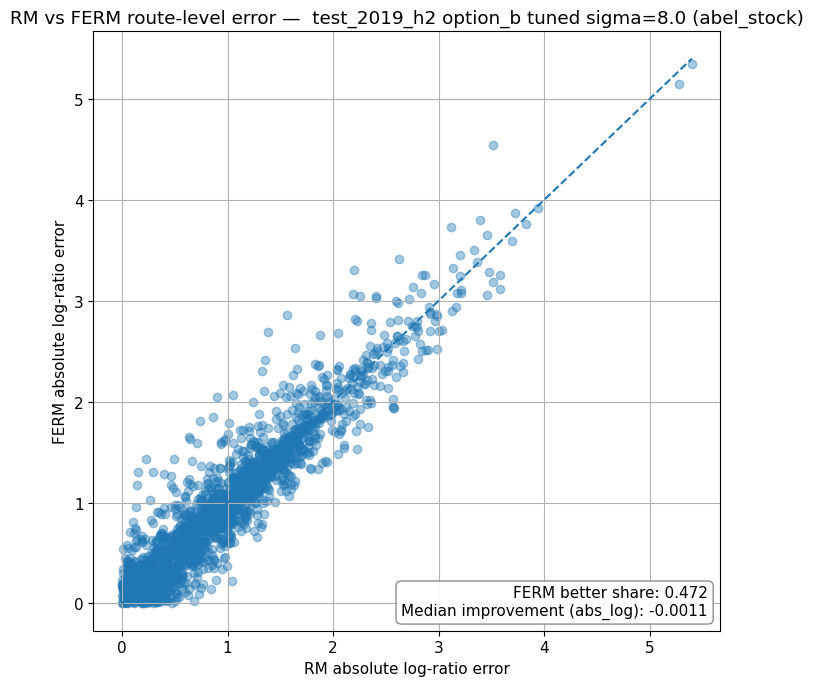

,period,abel_spec,sigma,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,zero_pred_share,zero_pred_observed_total
0,test_2019_h2,option_b,8.0,-0.001124,-0.008501,0.472464,0.201932,94728.0


In [126]:
# Tune the one-parameter Abel Option B on validation, then evaluate on test

import importlib
import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM, RM
from src.ferm.plotting import compare_rm_vs_ferm_routes, plot_rm_vs_ferm_error_scatter

required_names = [
    "pair_lookup",
    "country",
    "prepare_nodes",
    "build_abel_sigma_from_spec",
    "build_gravity_distance_matrix",
    "gravity_pairs",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError("Run the setup/main workflow cell first. Missing names: " + ", ".join(missing))

abel_sheet = abel_sheet_name if "abel_sheet_name" in globals() else "2005-10"
abel_distance_col = distance_col if "distance_col" in globals() else "dist"
abel_validation_label = "validation_2019_h1"
abel_test_label = "test_2019_h2"
abel_spec_to_tune = "option_b"

flows_val_abel = pair_lookup[abel_validation_label].rename({"total_migrants": "num_migrants"}, axis=1).copy()
flows_test_abel = pair_lookup[abel_test_label].rename({"total_migrants": "num_migrants"}, axis=1).copy()

nodes_val_abel = prepare_nodes(country, flows_val_abel)
nodes_test_abel = prepare_nodes(country, flows_test_abel)
D_val_abel = build_gravity_distance_matrix(nodes_val_abel, gravity_pairs, distance_col=abel_distance_col)
D_test_abel = build_gravity_distance_matrix(nodes_test_abel, gravity_pairs, distance_col=abel_distance_col)

rm_val_abel = RM(nodes=nodes_val_abel, flows=flows_val_abel, distance_matrix=D_val_abel).run()
rm_test_abel = RM(nodes=nodes_test_abel, flows=flows_test_abel, distance_matrix=D_test_abel).run()
comp_rm_val_abel = rm_val_abel.comparison.rename({"num_migrants": "total_migrants"}, axis=1)
comp_rm_test_abel = rm_test_abel.comparison.rename({"num_migrants": "total_migrants"}, axis=1)

TUNE_FAST = True
abel_tune_sigma_grid = [0.5, 1.0, 2.0, 5.0, 8.0] if TUNE_FAST else [0.25, 0.5, 1.0, 2.0, 5.0, 8.0, 12.0]
abel_tune_num_particles = 50000 if TUNE_FAST else 100000

Sigma_val = build_abel_sigma_from_spec(
    nodes=nodes_val_abel,
    spec_name=abel_spec_to_tune,
    abel_path="abel-database-s2.xlsx",
    sheet_name=abel_sheet,
)
vals = Sigma_val.to_numpy()[~np.eye(Sigma_val.shape[0], dtype=bool)]

abel_tune_rows = []
abel_tune_cache = {}

for sigma_value in abel_tune_sigma_grid:
    print(f"validation: spec={abel_spec_to_tune}, sigma={sigma_value}")
    result = FERM(
        nodes=nodes_val_abel,
        flows=flows_val_abel,
        features=Sigma_val,
        distance_matrix=D_val_abel,
    ).run(
        num_particles=abel_tune_num_particles,
        sigma=sigma_value,
        verbose=False,
    )
    comp_ferm_val = result.comparison.rename({"num_migrants": "total_migrants"}, axis=1)
    routes = compare_rm_vs_ferm_routes(comp_rm_val_abel, comp_ferm_val)
    pred_log = np.log10(comp_ferm_val["predicted_migrants"] + 1)
    obs_log = np.log10(comp_ferm_val["total_migrants"] + 1)

    row = {
        "abel_spec": abel_spec_to_tune,
        "abel_label": ABEL_SIGMA_SPECS[abel_spec_to_tune]["label"],
        "sigma": sigma_value,
        "num_particles": abel_tune_num_particles,
        "median_improvement_abs_log": routes["improvement_abs_log"].median(),
        "mean_improvement_abs_log": routes["improvement_abs_log"].mean(),
        "share_better_abs_log": (routes["improvement_abs_log"] > 0).mean(),
        "pearson_log": obs_log.corr(pred_log),
        "zero_pred_share": (comp_ferm_val["predicted_migrants"] <= 0).mean(),
        "zero_pred_observed_total": comp_ferm_val.loc[comp_ferm_val["predicted_migrants"] <= 0, "total_migrants"].sum(),
        "sigma_min": np.nanmin(vals),
        "sigma_p01": np.nanquantile(vals, 0.01),
        "sigma_median": np.nanmedian(vals),
        "sigma_p99": np.nanquantile(vals, 0.99),
        "sigma_max": np.nanmax(vals),
    }
    abel_tune_rows.append(row)
    abel_tune_cache[(abel_spec_to_tune, sigma_value)] = {
        "result": result,
        "comparison": comp_ferm_val,
        "routes": routes,
        "Sigma": Sigma_val,
    }

abel_tune_df = pd.DataFrame(abel_tune_rows).sort_values(
    ["median_improvement_abs_log", "share_better_abs_log", "pearson_log"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(abel_tune_df)

best = abel_tune_df.iloc[0]
print("Best validation Abel parameters:")
print(best[["abel_spec", "sigma", "median_improvement_abs_log", "share_better_abs_log", "pearson_log", "zero_pred_share"]])

Sigma_test_best = build_abel_sigma_from_spec(
    nodes=nodes_test_abel,
    spec_name=abel_spec_to_tune,
    abel_path="abel-database-s2.xlsx",
    sheet_name=abel_sheet,
)

best_test_result = FERM(
    nodes=nodes_test_abel,
    flows=flows_test_abel,
    features=Sigma_test_best,
    distance_matrix=D_test_abel,
).run(
    num_particles=abel_tune_num_particles,
    sigma=float(best["sigma"]),
    verbose=False,
)

comp_best_test = best_test_result.comparison.rename({"num_migrants": "total_migrants"}, axis=1)
abel_best_test_routes = plot_rm_vs_ferm_error_scatter(
    comp_rm_test_abel,
    comp_best_test,
    label=f"{abel_test_label} {abel_spec_to_tune} tuned sigma={best['sigma']}",
    metric="abs_log",
    niche_type="abel_stock",
)

display(pd.DataFrame([{
    "period": abel_test_label,
    "abel_spec": abel_spec_to_tune,
    "sigma": float(best["sigma"]),
    "median_improvement_abs_log": abel_best_test_routes["improvement_abs_log"].median(),
    "mean_improvement_abs_log": abel_best_test_routes["improvement_abs_log"].mean(),
    "share_better_abs_log": (abel_best_test_routes["improvement_abs_log"] > 0).mean(),
    "zero_pred_share": (comp_best_test["predicted_migrants"] <= 0).mean(),
    "zero_pred_observed_total": comp_best_test.loc[comp_best_test["predicted_migrants"] <= 0, "total_migrants"].sum(),
}]))


## 5. Diagnostics

Use these after the main run or after tuning to understand whether Abel is changing predictions too much, too little, or in the wrong routes.

Pearson correlations among log predictions and observed flows:


,log_pred_rm,log_pred_gdp_ferm,log_pred_abel_ferm,log_num_migrants
log_pred_rm,1.000000,0.919023,0.968800,0.645768
log_pred_gdp_ferm,0.919023,1.000000,0.899399,0.700854
log_pred_abel_ferm,0.968800,0.899399,1.000000,0.645791
log_num_migrants,0.645768,0.700854,0.645791,1.000000


,variant,corr_with_RM_log_pred,corr_with_observed_log,median_abs_log_move_from_RM,mean_abs_log_move_from_RM
0,GDP-FERM,0.919023,0.700854,0.284666,0.401857
1,Abel-FERM,0.968800,0.645791,0.162046,0.234992


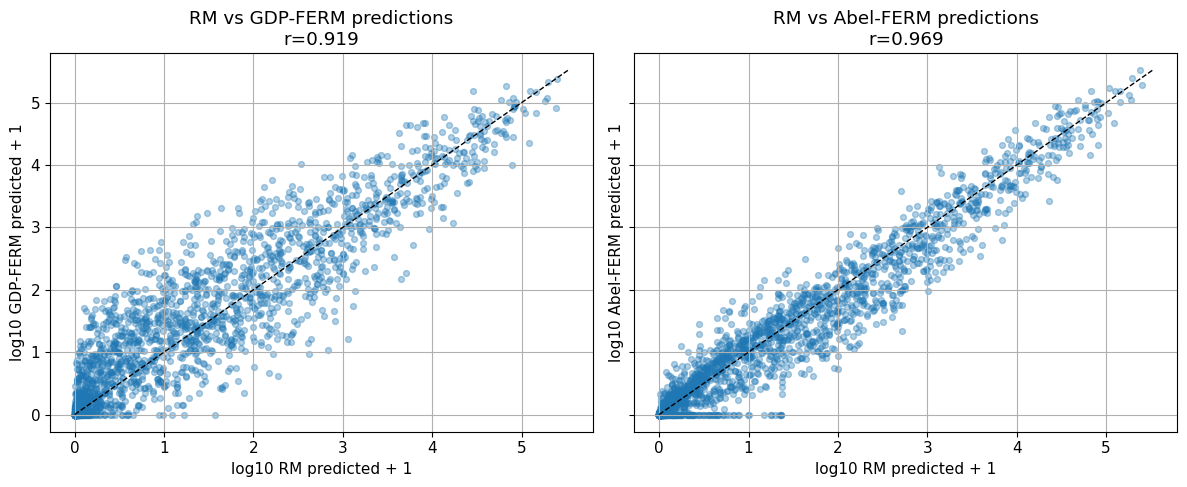

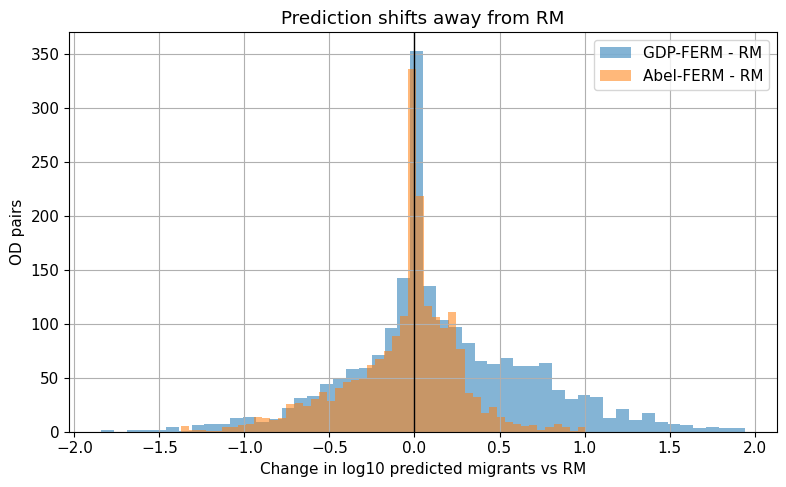

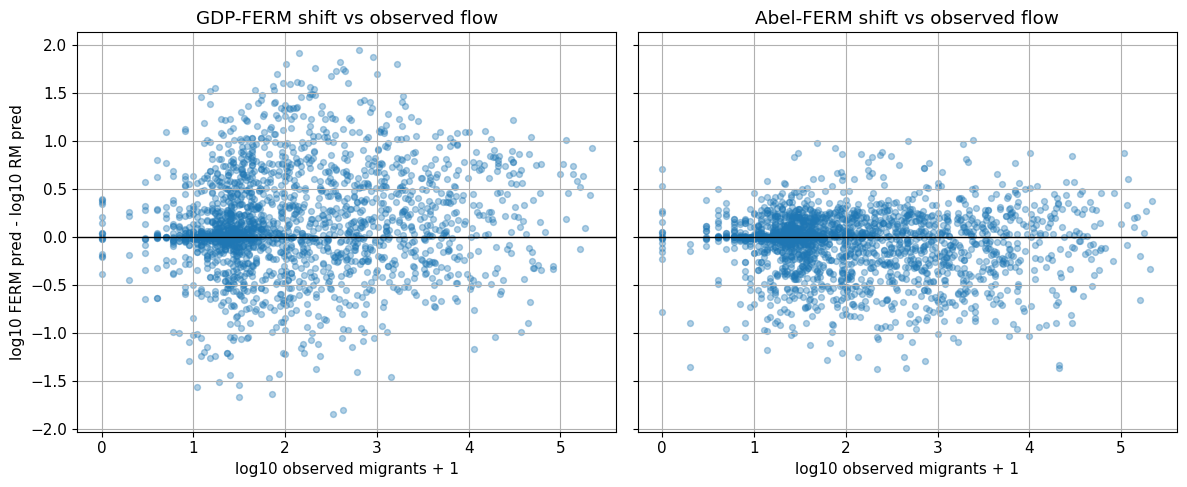

In [127]:
# Diagnostics: how similar are RM, GDP-FERM, and Abel-FERM predictions?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_names = ["comparisons_rm", "comparisons_ferm", "comparisons_abel", "only_label"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError("Run the main workflow cell first. Missing names: " + ", ".join(missing))


def prediction_table_for_diagnostics(label):
    rm = comparisons_rm[label]["comparison"].copy()
    gdp = comparisons_ferm[label]["comparison"].copy()
    abel = comparisons_abel[label]["comparison"].copy()

    keep = ["country_from", "country_to", "num_migrants", "predicted_migrants"]
    rm = rm[keep].rename(columns={"predicted_migrants": "pred_rm"})
    gdp = gdp[["country_from", "country_to", "predicted_migrants"]].rename(
        columns={"predicted_migrants": "pred_gdp_ferm"}
    )
    abel = abel[["country_from", "country_to", "predicted_migrants"]].rename(
        columns={"predicted_migrants": "pred_abel_ferm"}
    )

    out = rm.merge(gdp, on=["country_from", "country_to"], how="inner")
    out = out.merge(abel, on=["country_from", "country_to"], how="inner")

    for col in ["num_migrants", "pred_rm", "pred_gdp_ferm", "pred_abel_ferm"]:
        out[f"log_{col}"] = np.log10(out[col] + 1.0)

    out["delta_log_gdp_vs_rm"] = out["log_pred_gdp_ferm"] - out["log_pred_rm"]
    out["delta_log_abel_vs_rm"] = out["log_pred_abel_ferm"] - out["log_pred_rm"]
    out["abs_delta_log_gdp_vs_rm"] = out["delta_log_gdp_vs_rm"].abs()
    out["abs_delta_log_abel_vs_rm"] = out["delta_log_abel_vs_rm"].abs()

    return out


diag_df = prediction_table_for_diagnostics(only_label)

corr_cols = ["log_pred_rm", "log_pred_gdp_ferm", "log_pred_abel_ferm", "log_num_migrants"]
corr_table = diag_df[corr_cols].corr(method="pearson")
print("Pearson correlations among log predictions and observed flows:")
display(corr_table)

summary = pd.DataFrame([
    {
        "variant": "GDP-FERM",
        "corr_with_RM_log_pred": diag_df["log_pred_rm"].corr(diag_df["log_pred_gdp_ferm"]),
        "corr_with_observed_log": diag_df["log_num_migrants"].corr(diag_df["log_pred_gdp_ferm"]),
        "median_abs_log_move_from_RM": diag_df["abs_delta_log_gdp_vs_rm"].median(),
        "mean_abs_log_move_from_RM": diag_df["abs_delta_log_gdp_vs_rm"].mean(),
    },
    {
        "variant": "Abel-FERM",
        "corr_with_RM_log_pred": diag_df["log_pred_rm"].corr(diag_df["log_pred_abel_ferm"]),
        "corr_with_observed_log": diag_df["log_num_migrants"].corr(diag_df["log_pred_abel_ferm"]),
        "median_abs_log_move_from_RM": diag_df["abs_delta_log_abel_vs_rm"].median(),
        "mean_abs_log_move_from_RM": diag_df["abs_delta_log_abel_vs_rm"].mean(),
    },
])
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
variants = [
    ("GDP-FERM", "log_pred_gdp_ferm"),
    ("Abel-FERM", "log_pred_abel_ferm"),
]

lims = [
    min(diag_df["log_pred_rm"].min(), diag_df["log_pred_gdp_ferm"].min(), diag_df["log_pred_abel_ferm"].min()),
    max(diag_df["log_pred_rm"].max(), diag_df["log_pred_gdp_ferm"].max(), diag_df["log_pred_abel_ferm"].max()),
]

for ax, (name, col) in zip(axes, variants):
    ax.scatter(diag_df["log_pred_rm"], diag_df[col], alpha=0.35, s=18)
    ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
    r = diag_df["log_pred_rm"].corr(diag_df[col])
    ax.set_title(f"RM vs {name} predictions\nr={r:.3f}")
    ax.set_xlabel("log10 RM predicted + 1")
    ax.set_ylabel(f"log10 {name} predicted + 1")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(diag_df["delta_log_gdp_vs_rm"], bins=50, alpha=0.55, label="GDP-FERM - RM")
plt.hist(diag_df["delta_log_abel_vs_rm"], bins=50, alpha=0.55, label="Abel-FERM - RM")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Change in log10 predicted migrants vs RM")
plt.ylabel("OD pairs")
plt.title("Prediction shifts away from RM")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].scatter(diag_df["log_num_migrants"], diag_df["delta_log_gdp_vs_rm"], alpha=0.35, s=18)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("GDP-FERM shift vs observed flow")
axes[0].set_xlabel("log10 observed migrants + 1")
axes[0].set_ylabel("log10 FERM pred - log10 RM pred")

axes[1].scatter(diag_df["log_num_migrants"], diag_df["delta_log_abel_vs_rm"], alpha=0.35, s=18)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Abel-FERM shift vs observed flow")
axes[1].set_xlabel("log10 observed migrants + 1")

plt.tight_layout()
plt.show()


In [128]:
# Extra diagnostic: prediction-ratio, Sigma range, and Abel zero-prediction routes
# Run after the diagnostics cell above.

if "diag_df" not in globals():
    raise NameError("Run the diagnostics cell first so `diag_df` exists.")

ratio_summary = pd.DataFrame([
    {
        "variant": "GDP-FERM / RM",
        "delta_log_min": diag_df["delta_log_gdp_vs_rm"].min(),
        "delta_log_p01": diag_df["delta_log_gdp_vs_rm"].quantile(0.01),
        "delta_log_p50": diag_df["delta_log_gdp_vs_rm"].median(),
        "delta_log_p99": diag_df["delta_log_gdp_vs_rm"].quantile(0.99),
        "delta_log_max": diag_df["delta_log_gdp_vs_rm"].max(),
        "ratio_p01": 10 ** diag_df["delta_log_gdp_vs_rm"].quantile(0.01),
        "ratio_p99": 10 ** diag_df["delta_log_gdp_vs_rm"].quantile(0.99),
    },
    {
        "variant": "Abel-FERM / RM",
        "delta_log_min": diag_df["delta_log_abel_vs_rm"].min(),
        "delta_log_p01": diag_df["delta_log_abel_vs_rm"].quantile(0.01),
        "delta_log_p50": diag_df["delta_log_abel_vs_rm"].median(),
        "delta_log_p99": diag_df["delta_log_abel_vs_rm"].quantile(0.99),
        "delta_log_max": diag_df["delta_log_abel_vs_rm"].max(),
        "ratio_p01": 10 ** diag_df["delta_log_abel_vs_rm"].quantile(0.01),
        "ratio_p99": 10 ** diag_df["delta_log_abel_vs_rm"].quantile(0.99),
    },
])
display(ratio_summary)

if "comparisons_abel" in globals() and only_label in comparisons_abel:
    Sigma_abel_current = comparisons_abel[only_label]["Sigma"]
    off_diag = ~np.eye(Sigma_abel_current.shape[0], dtype=bool)
    vals = Sigma_abel_current.to_numpy()[off_diag]
    display(pd.DataFrame([{
        "Sigma": comparisons_abel[only_label].get("spec_label", "Abel Sigma"),
        "min": np.nanmin(vals),
        "p01": np.nanquantile(vals, 0.01),
        "median": np.nanmedian(vals),
        "p99": np.nanquantile(vals, 0.99),
        "max": np.nanmax(vals),
    }]))

zero_mask = diag_df["pred_abel_ferm"] <= 0
zero_summary = pd.DataFrame([{
    "zero_pred_routes": int(zero_mask.sum()),
    "zero_pred_share": zero_mask.mean(),
    "observed_total_on_zero_pred_routes": diag_df.loc[zero_mask, "num_migrants"].sum(),
    "median_observed_on_zero_pred_routes": diag_df.loc[zero_mask, "num_migrants"].median(),
    "median_rm_pred_on_zero_pred_routes": diag_df.loc[zero_mask, "pred_rm"].median(),
}])
display(zero_summary)

if zero_mask.any():
    zero_routes = diag_df.loc[zero_mask].copy()
    if "comparisons_abel" in globals() and only_label in comparisons_abel:
        Sigma_abel_current = comparisons_abel[only_label]["Sigma"]
        zero_routes["Sigma_abel"] = [
            Sigma_abel_current.loc[o, d]
            if o in Sigma_abel_current.index and d in Sigma_abel_current.columns
            else np.nan
            for o, d in zip(zero_routes["country_from"], zero_routes["country_to"])
        ]
    display(
        zero_routes.sort_values("num_migrants", ascending=False)[
            ["country_from", "country_to", "num_migrants", "pred_rm", "pred_gdp_ferm", "pred_abel_ferm"]
            + (["Sigma_abel"] if "Sigma_abel" in zero_routes.columns else [])
        ].head(20)
    )


,variant,delta_log_min,delta_log_p01,delta_log_p50,delta_log_p99,delta_log_max,ratio_p01,ratio_p99
0,GDP-FERM / RM,-1.840604,-1.211594,0.049517,1.544587,1.942448,0.061434,35.041877
1,Abel-FERM / RM,-1.371390,-1.030138,-0.002467,0.756708,1.008061,0.093296,5.710947


,Sigma,min,p01,median,p99,max
0,Abel Option B: expected-stock residual tanh,-0.6,-0.6,-0.6,0.99806,0.999945


,zero_pred_routes,zero_pred_share,observed_total_on_zero_pred_routes,median_observed_on_zero_pred_routes,median_rm_pred_on_zero_pred_routes
0,318,0.153623,95256.0,21.0,0.035442


,country_from,country_to,num_migrants,pred_rm,pred_gdp_ferm,pred_abel_ferm,Sigma_abel
73,ARE,NPL,21080.0,22.174679,136.298850,0.0,-0.600000
212,BGD,QAT,20855.0,20.815038,135.571924,0.0,-0.101900
1337,NPL,QAT,17567.0,2.578170,36.507388,0.0,-0.536766
256,BHR,PHL,6137.0,1.036322,4.890822,0.0,-0.600000
1326,NPL,KWT,5005.0,4.167027,13.907576,0.0,-0.563960
1313,NPL,CYP,2815.0,0.772073,3.476894,0.0,-0.514270
185,BGD,BRN,2578.0,5.076996,45.190641,0.0,-0.530899
253,BHR,NPL,2123.0,0.558444,1.630274,0.0,-0.600000
1310,NPL,BHR,1812.0,1.453744,10.430682,0.0,-0.538837
1320,NPL,JOR,1164.0,6.559485,5.215341,0.0,-0.590574


## 6. Optional Relational Feature Plots

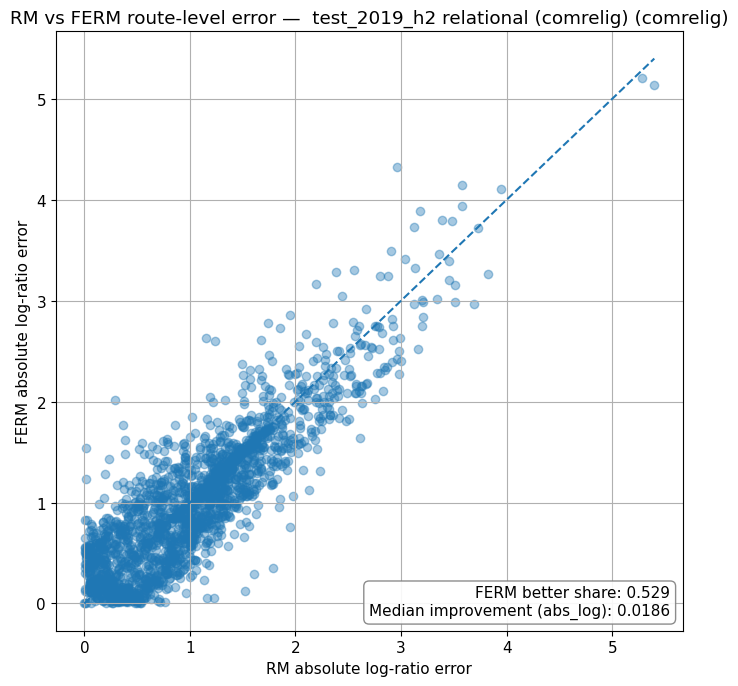

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,residual_rm,abs_error_rm,log_ratio_rm,abs_log_ratio_rm,predicted_ferm,residual_ferm,abs_error_ferm,log_ratio_ferm,abs_log_ratio_ferm,improvement_abs_error,improvement_abs_log
0,AFG,ARE,Afghanistan,United Arab Emirates,5743.0,5.044662,-5737.955338,5737.955338,-2.977842,2.977842,17.104213,-5725.895787,5725.895787,-2.501435,2.501435,12.059551,0.476408
1,AFG,ARM,Afghanistan,Armenia,5.0,1.461523,-3.538477,3.538477,-0.386947,0.386947,0.417176,-4.582824,4.582824,-0.626727,0.626727,-1.044347,-0.239780
2,AFG,AZE,Afghanistan,Azerbaijan,101.0,5.067951,-95.932049,95.932049,-1.225558,1.225558,17.521389,-83.478611,83.478611,-0.740927,0.740927,12.453438,0.484631
3,AFG,BGD,Afghanistan,Bangladesh,55.0,71.826662,16.826662,16.826662,0.114102,0.114102,180.220001,125.220001,125.220001,0.510018,0.510018,-108.393339,-0.395916
4,AFG,BHR,Afghanistan,Bahrain,22.0,0.743880,-21.256120,21.256120,-1.120211,1.120211,2.085880,-19.914120,19.914120,-0.872349,0.872349,1.342000,0.247862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,YEM,TLS,Yemen,East Timor,2.0,0.208860,-1.791140,1.791140,-0.394745,0.394745,0.000000,-2.000000,2.000000,-0.477121,0.477121,-0.208860,-0.082376
2066,YEM,TUR,Yemen,Turkey,693.0,513.912842,-179.087158,179.087158,-0.129626,0.129626,215.171655,-477.828345,477.828345,-0.506561,0.506561,-298.741187,-0.376935
2067,YEM,TWN,Yemen,Taiwan,13.0,4.141623,-8.858377,8.858377,-0.435028,0.435028,2.733578,-10.266422,10.266422,-0.574003,0.574003,-1.408045,-0.138975
2068,YEM,UZB,Yemen,Uzbekistan,34.0,12.133632,-21.866368,21.866368,-0.425683,0.425683,26.554760,-7.445240,7.445240,-0.103871,0.103871,14.421127,0.321812


In [129]:
# Optional: relational feature scatter plots

plot_feature = "comrelig"

comp_rel = comparisons_relational[only_label][plot_feature]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_rel,
    label=f"{only_label} relational ({plot_feature})",
    metric="abs_log",
    niche_type=plot_feature,
)



## 7. Optional Route Maps

In [130]:
import importlib
import src.ferm.plotting as plotting
importlib.reload(plotting)

from src.ferm.plotting import plot_ferm_vs_rm_route_change_ex


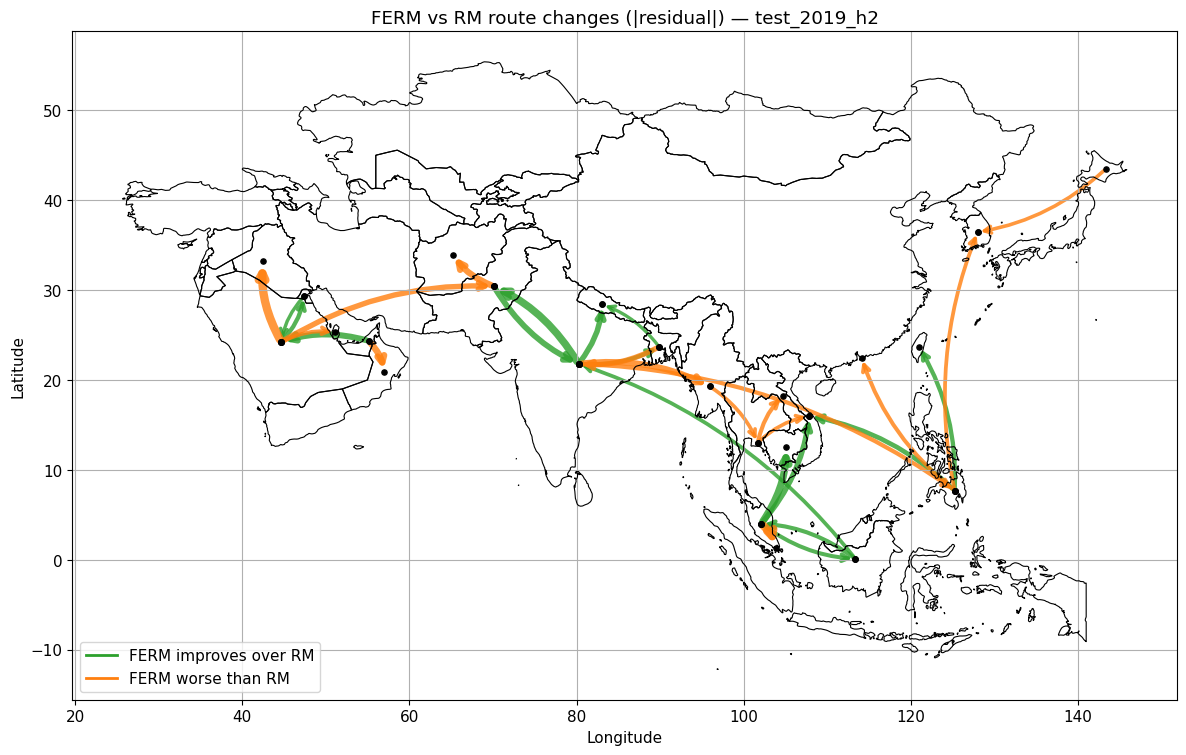

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,predicted_ferm,residual_rm,residual_ferm,improvement_abs_error,improvement_abs_log,route_change
0,IND,PAK,India,Pakistan,0.0,190618.961680,112176.701152,190618.961680,112176.701152,78442.260529,0.230262,Improved
1,MYS,KHM,Malaysia,Cambodia,4257.0,122194.681085,47300.552379,117937.681085,43043.552379,74894.128705,0.412180,Improved
2,ARE,SAU,United Arab Emirates,Saudi Arabia,3800.0,81635.462627,21340.376152,77835.462627,17540.376152,60295.086474,0.582662,Improved
3,PAK,IND,Pakistan,India,0.0,250195.873528,193425.141257,250195.873528,193425.141257,56770.732271,0.111767,Improved
4,IND,NPL,India,Nepal,83188.0,29281.834387,84271.186805,-53906.165613,1083.186805,52822.978809,0.447834,Improved
5,MYS,VNM,Malaysia,Vietnam,8967.0,182916.556922,130876.100682,173949.556922,121909.100682,52040.456240,0.145392,Improved
6,PHL,VNM,Philippines,Vietnam,51624.0,143941.223945,101103.610822,92317.223945,49479.610822,42837.613123,0.153417,Improved
7,SAU,KWT,Saudi Arabia,Kuwait,4998.0,81045.916646,43510.666836,76047.916646,38512.666836,37535.249810,0.270131,Improved
8,PHL,TWN,Philippines,Taiwan,27575.0,69437.554351,31997.105822,41862.554351,4422.105822,37440.448529,0.336476,Improved
9,IDN,MYS,Indonesia,Malaysia,115531.0,30029.201906,65326.070976,-85501.798094,-50204.929024,35296.869070,0.337535,Improved


In [131]:
# plot map
from src.ferm.plotting import plot_ferm_vs_rm_route_change_ex

comp_rel = comparisons_relational[only_label]["scaled_sci_2021"]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)
plot_ferm_vs_rm_route_change_ex(
    comp_rm,
    comp_abel,
    label=only_label,
    metric="abs_error",
    country_geo=country_geo,
    continent_gdf=continent_gdf,)


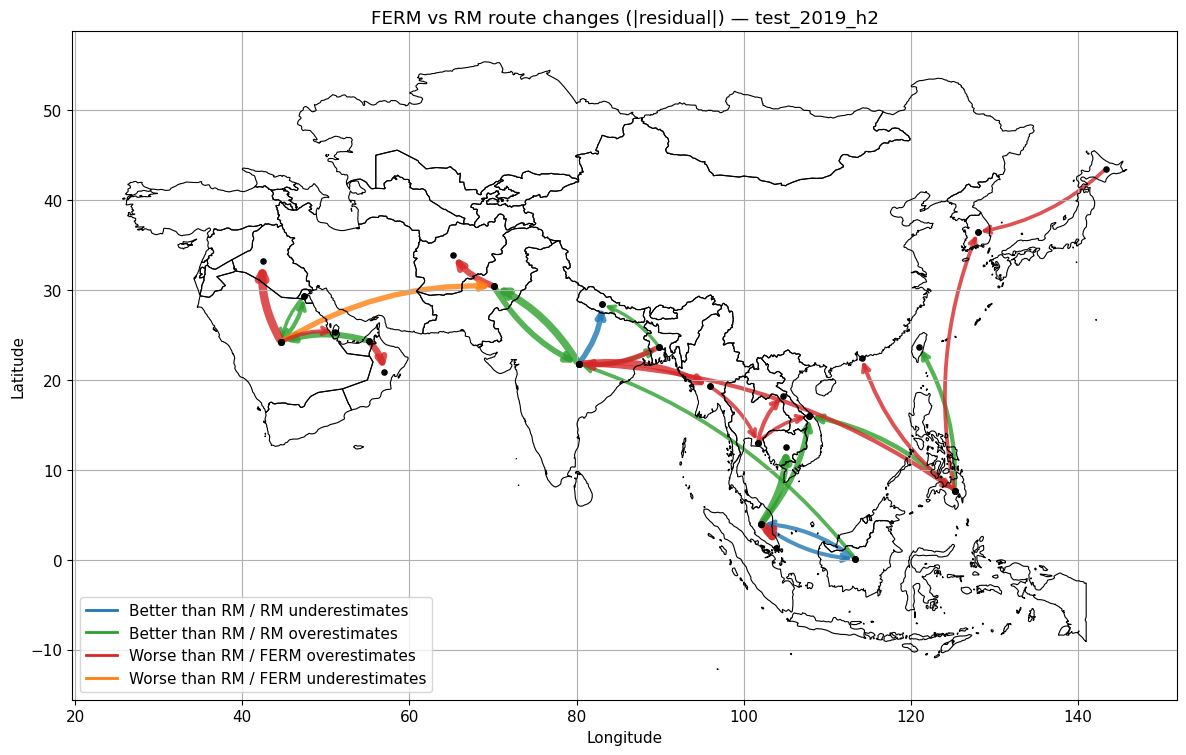

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,predicted_ferm,residual_rm,residual_ferm,improvement_abs_error,improvement_abs_log,route_change,route_class
0,IND,PAK,India,Pakistan,0.0,190618.961680,112176.701152,190618.961680,112176.701152,78442.260529,0.230262,Improved,Better / RM overestimates
1,MYS,KHM,Malaysia,Cambodia,4257.0,122194.681085,47300.552379,117937.681085,43043.552379,74894.128705,0.412180,Improved,Better / RM overestimates
2,ARE,SAU,United Arab Emirates,Saudi Arabia,3800.0,81635.462627,21340.376152,77835.462627,17540.376152,60295.086474,0.582662,Improved,Better / RM overestimates
3,PAK,IND,Pakistan,India,0.0,250195.873528,193425.141257,250195.873528,193425.141257,56770.732271,0.111767,Improved,Better / RM overestimates
4,IND,NPL,India,Nepal,83188.0,29281.834387,84271.186805,-53906.165613,1083.186805,52822.978809,0.447834,Improved,Better / RM underestimates
5,MYS,VNM,Malaysia,Vietnam,8967.0,182916.556922,130876.100682,173949.556922,121909.100682,52040.456240,0.145392,Improved,Better / RM overestimates
6,PHL,VNM,Philippines,Vietnam,51624.0,143941.223945,101103.610822,92317.223945,49479.610822,42837.613123,0.153417,Improved,Better / RM overestimates
7,SAU,KWT,Saudi Arabia,Kuwait,4998.0,81045.916646,43510.666836,76047.916646,38512.666836,37535.249810,0.270131,Improved,Better / RM overestimates
8,PHL,TWN,Philippines,Taiwan,27575.0,69437.554351,31997.105822,41862.554351,4422.105822,37440.448529,0.336476,Improved,Better / RM overestimates
9,IDN,MYS,Indonesia,Malaysia,115531.0,30029.201906,65326.070976,-85501.798094,-50204.929024,35296.869070,0.337535,Improved,Better / RM underestimates


In [132]:
from src.ferm.plotting import plot_ferm_vs_rm_route_change

plot_ferm_vs_rm_route_change(
    comp_rm,
    comp_abel,
    label=only_label,
    metric="abs_error",
    country_geo=country_geo,
    continent_gdf=continent_gdf,)


## Appendix. CEPII Feature Coverage

Optional exploration cell for CEPII bilateral feature missingness and coverage. Not needed for standard Abel tests.

In [ ]:
# Optional CEPII feature coverage inspection

# Inspect CEPII bilateral features and missingness
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cepii_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")

# Keep as many non-binary bilateral features as possible
feature_cols = [
    "distw_harmonic",
    "distw_arithmetic",
    "dist",
    "distcap",
    "diplo_disagreement",
    "scaled_sci_2021",
    "comrelig",
    "col_dep_end_year",
    "sever_year",
    "rta_coverage",
    "rta_type",
    "tradeflow_comtrade_o",
    "tradeflow_comtrade_d",
    "tradeflow_baci",
    "manuf_tradeflow_baci",
    "tradeflow_imf_o",
    "tradeflow_imf_d",
]

cepii = pd.read_csv(
    cepii_path,
    usecols=["year", "iso3_o", "iso3_d"] + feature_cols,
)

print("Rows:", len(cepii))
print("Years:", sorted(cepii["year"].dropna().unique().tolist()))
print("Columns:", cepii.columns.tolist())

# 1) overall feature coverage
coverage = pd.DataFrame({
    "non_null": cepii[feature_cols].notna().sum(),
    "coverage_share": cepii[feature_cols].notna().mean(),
    "n_unique": cepii[feature_cols].nunique(dropna=True),
    "min": cepii[feature_cols].min(numeric_only=False),
    "max": cepii[feature_cols].max(numeric_only=False),
}).sort_values("coverage_share", ascending=False)

display(coverage)

# 2) coverage by year
coverage_by_year = (
    cepii.groupby("year")[feature_cols]
    .apply(lambda x: x.notna().mean())
    .T
)

plt.figure(figsize=(12, 6))
plt.imshow(coverage_by_year.values, aspect="auto", cmap="viridis")
plt.colorbar(label="non-missing share")
plt.xticks(range(len(coverage_by_year.columns)), coverage_by_year.columns)
plt.yticks(range(len(coverage_by_year.index)), coverage_by_year.index)
plt.title("CEPII feature coverage by year")
plt.tight_layout()
plt.show()

display(coverage_by_year)

# 3) country-level missingness:
# for each ISO3, how many outgoing/incoming corridors have each feature available?
outgoing_country_coverage = (
    cepii.groupby("iso3_o")[feature_cols]
    .apply(lambda x: x.notna().mean())
    .sort_index()
)

incoming_country_coverage = (
    cepii.groupby("iso3_d")[feature_cols]
    .apply(lambda x: x.notna().mean())
    .sort_index()
)

# average across features, useful to spot countries with poor bilateral coverage
outgoing_summary = outgoing_country_coverage.mean(axis=1).sort_values()
incoming_summary = incoming_country_coverage.mean(axis=1).sort_values()

print("\nWorst outgoing coverage:")
display(outgoing_summary.head(20).rename("mean_feature_coverage").to_frame())

print("\nWorst incoming coverage:")
display(incoming_summary.head(20).rename("mean_feature_coverage").to_frame())

# 4) optional: inspect one country
inspect_iso3 = "IND"   # change this
country_view = cepii[(cepii["iso3_o"] == inspect_iso3) | (cepii["iso3_d"] == inspect_iso3)].copy()

print(f"\nRows involving {inspect_iso3}: {len(country_view)}")

country_feature_coverage = pd.DataFrame({
    "non_null": country_view[feature_cols].notna().sum(),
    "coverage_share": country_view[feature_cols].notna().mean(),
}).sort_values("coverage_share", ascending=False)

display(country_feature_coverage)

# 5) optional: build a "best available Sigma input" table
# idea: keep all rows, and count how many bilateral features are available on each corridor
cepii["n_available_features"] = cepii[feature_cols].notna().sum(axis=1)

best_corridors = cepii.sort_values(
    ["n_available_features", "year"],
    ascending=[False, False]
)

display(best_corridors.head(20))
